In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install ultralytics pandas scikit-learn
from ultralytics import YOLO

In [6]:
import zipfile, os

zip_dir = "/content/drive/MyDrive/dataset/images"
extract_path = "/content/dataset_images"

os.makedirs(extract_path, exist_ok=True)

for file in os.listdir(zip_dir):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(zip_dir, file), 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("✅ All ZIP files extracted")

# Add a new cell to list the contents of extract_path
print(f"\nContents of {extract_path}:")
for item in os.listdir(extract_path):
    print(f"- {item}")


✅ All ZIP files extracted

Contents of /content/dataset_images:
- imgs_part_2
- imgs_part_3
- imgs_part_1


In [7]:
import pandas as pd

csv_path = "/content/drive/MyDrive/dataset/metadata.csv"
df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

  patient_id  lesion_id  smoke  drink background_father background_mother  \
0   PAT_1516       1765    NaN    NaN               NaN               NaN   
1     PAT_46        881  False  False         POMERANIA         POMERANIA   
2   PAT_1545       1867    NaN    NaN               NaN               NaN   
3   PAT_1989       4061    NaN    NaN               NaN               NaN   
4    PAT_684       1302  False   True         POMERANIA         POMERANIA   

   age pesticide  gender skin_cancer_history  ... diameter_2 diagnostic  \
0    8       NaN     NaN                 NaN  ...        NaN        NEV   
1   55     False  FEMALE                True  ...        5.0        BCC   
2   77       NaN     NaN                 NaN  ...        NaN        ACK   
3   75       NaN     NaN                 NaN  ...        NaN        ACK   
4   79     False    MALE                True  ...        5.0        BCC   

    itch   grew   hurt  changed  bleed elevation                 img_id  \
0  False  F

In [8]:
print(df[['img_id','diagnostic']].head())

                  img_id diagnostic
0  PAT_1516_1765_530.png        NEV
1     PAT_46_881_939.png        BCC
2  PAT_1545_1867_547.png        ACK
3  PAT_1989_4061_934.png        ACK
4   PAT_684_1302_588.png        BCC


In [9]:
# malignant classes
malignant = ['BCC', 'MEL', 'SCC']

def convert_label(x):
    if x in malignant:
        return "malignant"
    else:
        return "benign"

df['label'] = df['diagnostic'].apply(convert_label)

print(df['label'].value_counts())

label
benign       1209
malignant    1089
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [11]:
import shutil
import os

base_out = "/content/data"

def create_dataset(data, split):
    for _, row in data.iterrows():
        img_name = row['img_id']
        label = row['label']

        dst = os.path.join(base_out, split, label)
        os.makedirs(dst, exist_ok=True)

        src_found = False
        # Search for the image in all 'imgs_part_X' subdirectories
        for part_dir in os.listdir("/content/dataset_images"):
            # Ensure it's a directory and starts with 'imgs_part_'
            if os.path.isdir(os.path.join("/content/dataset_images", part_dir)) and part_dir.startswith('imgs_part_'):
                potential_src = os.path.join("/content/dataset_images", part_dir, img_name)
                if os.path.exists(potential_src):
                    shutil.copy(potential_src, os.path.join(dst, img_name))
                    src_found = True
                    break # Found and copied, move to next image

        if not src_found:
            print(f"Warning: Source image not found: {img_name} in any part directory.")

# Clear existing data before re-creating to avoid conflicts and ensure a clean state
if os.path.exists(base_out):
    shutil.rmtree(base_out)

create_dataset(train_df, "train")
create_dataset(val_df, "val")

print("✅ Dataset Ready")

✅ Dataset Ready


In [12]:
import yaml

# Create data.yaml for YOLO
data_yaml_content = {
    'path': '/content/data',
    'train': 'train',
    'val': 'val',
    'names': {0: 'benign', 1: 'malignant'}
}

data_yaml_path = '/content/data.yaml'
with open(data_yaml_path, 'w') as file:
    yaml.dump(data_yaml_content, file, default_flow_style=False)

print(f"✅ Created {data_yaml_path}")

model = YOLO("yolov8s-cls.pt")

model.train(
    data="/content/data",

    epochs=25,              # increase epochs
    imgsz=224,
    batch=32,
    device=0,

    # 🔥 Regularization
    dropout=0.3,

    # 🔥 Data Augmentation (VERY IMPORTANT)
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.5,
    fliplr=0.5,

    # 🔥 Optimization
    lr0=0.001,
    weight_decay=0.0005,

    # 🔥 Prevent Overfitting
    patience=5,            # early stopping

    # 🔥 Auto Save
    project="/content/drive/MyDrive/skin_cancer_project",
    name="exp_improved",

    pretrained=True
)


✅ Created /content/data.yaml
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_improved3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fafa9f259d0>
curves: []
curves_results: []
fitness: 0.917391300201416
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.834782600402832, 'metrics/accuracy_top5': 1.0, 'fitness': 0.917391300201416}
save_dir: PosixPath('/content/drive/MyDrive/skin_cancer_project/exp_improved3')
speed: {'preprocess': 0.1103714586979945, 'inference': 0.4031141239070364, 'loss': 0.00020461739436343675, 'postprocess': 0.00033630869992244385}
top1: 0.834782600402832
top5: 1.0

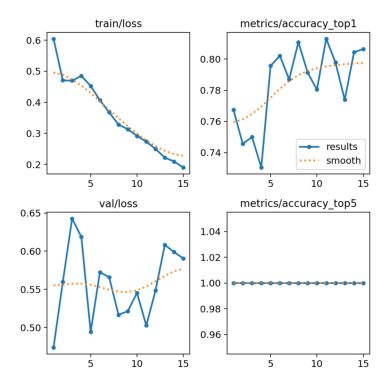

In [13]:
import cv2
import matplotlib.pyplot as plt

def show_image(path):
    img = cv2.imread(path)
    if img is None:
        print(f"Error: Unable to load image from {path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_image("/content/drive/MyDrive/skin_cancer_project/exp_binary4/results.png")

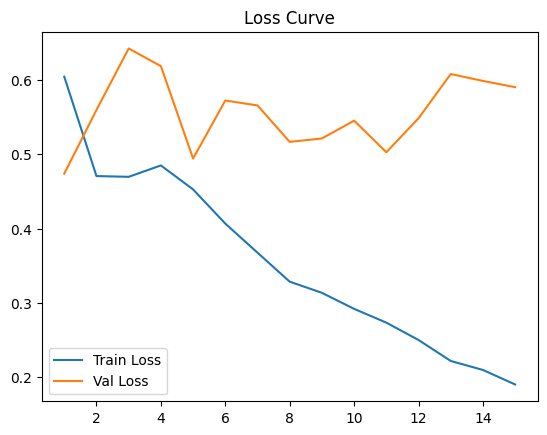

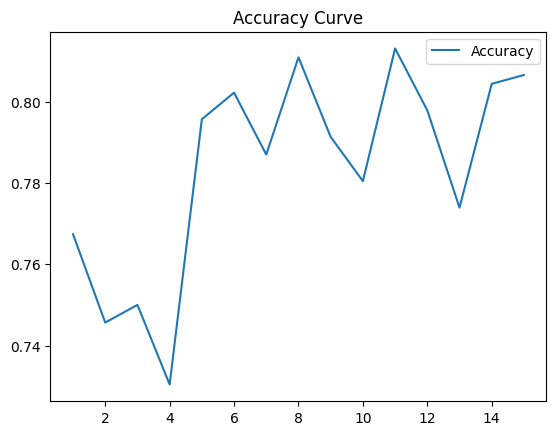

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df_res = pd.read_csv("/content/drive/MyDrive/skin_cancer_project/exp_binary4/results.csv")

# Loss
plt.plot(df_res['epoch'], df_res['train/loss'], label='Train Loss')
plt.plot(df_res['epoch'], df_res['val/loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

# Accuracy
plt.plot(df_res['epoch'], df_res['metrics/accuracy_top1'], label='Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [15]:
import os

model = YOLO("/content/drive/MyDrive/skin_cancer_project/exp_binary4/weights/best.pt")

# Create a list of all image paths in the validation set
val_image_paths = []
for _, row in val_df.iterrows():
    img_name = row['img_id']
    label = row['label']
    img_path = os.path.join("/content/data/val", label, img_name)
    if os.path.exists(img_path):
        val_image_paths.append(img_path)
    else:
        print(f"Warning: Validation image not found at {img_path}")

print(f"Found {len(val_image_paths)} images for prediction in the validation set.")

results = model.predict(
    source=val_image_paths, # Pass the list of image paths
    save=True
)

Found 460 images for prediction in the validation set.

0: 224x224 malignant 1.00, benign 0.00, 0.6ms
1: 224x224 benign 0.91, malignant 0.09, 0.6ms
2: 224x224 benign 0.98, malignant 0.02, 0.6ms
3: 224x224 benign 0.97, malignant 0.03, 0.6ms
4: 224x224 malignant 1.00, benign 0.00, 0.6ms
5: 224x224 malignant 0.99, benign 0.01, 0.6ms
6: 224x224 benign 0.85, malignant 0.15, 0.6ms
7: 224x224 malignant 1.00, benign 0.00, 0.6ms
8: 224x224 malignant 0.59, benign 0.41, 0.6ms
9: 224x224 malignant 0.76, benign 0.24, 0.6ms
10: 224x224 malignant 0.71, benign 0.29, 0.6ms
11: 224x224 malignant 0.98, benign 0.02, 0.6ms
12: 224x224 benign 1.00, malignant 0.00, 0.6ms
13: 224x224 malignant 0.97, benign 0.03, 0.6ms
14: 224x224 malignant 1.00, benign 0.00, 0.6ms
15: 224x224 malignant 0.94, benign 0.06, 0.6ms
16: 224x224 benign 0.97, malignant 0.03, 0.6ms
17: 224x224 benign 0.99, malignant 0.01, 0.6ms
18: 224x224 benign 1.00, malignant 0.00, 0.6ms
19: 224x224 benign 1.00, malignant 0.00, 0.6ms
20: 224x224 be

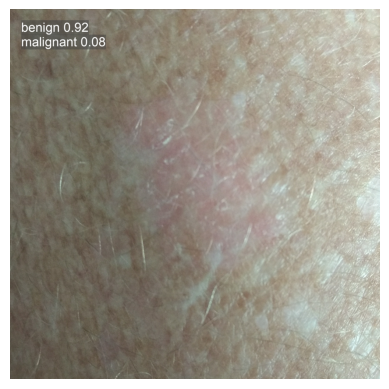

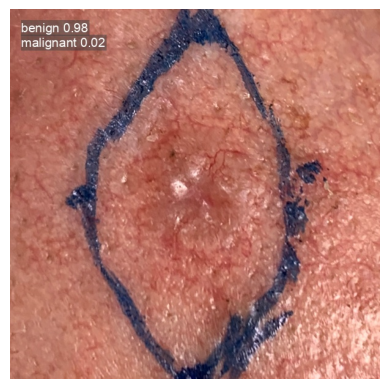

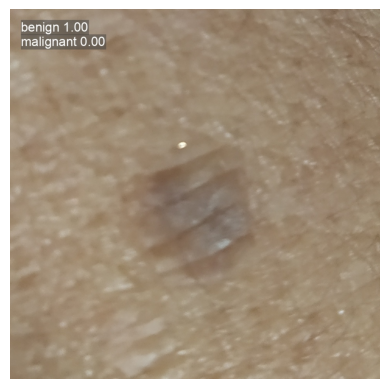

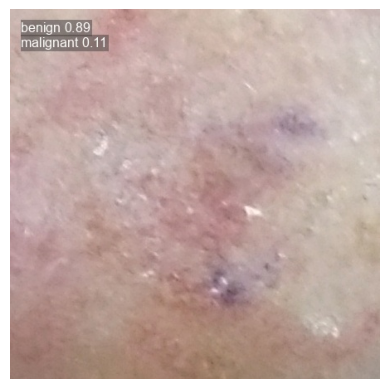

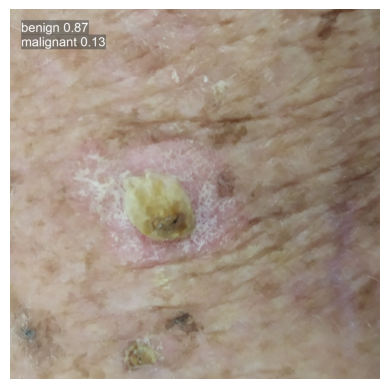

In [16]:
import glob

preds = glob.glob("runs/classify/predict/*.jpg")

for img in preds[:5]:
    show_image(img)